# Shoe SDF / mSDF Debugger

This notebook visualizes the two fields used by GShell:

```text
SDF  -> creates the watertight shoe surface
mSDF -> cuts that watertight surface into the final open shell
```

The important distinction is that mSDF is not an inside/outside field in 3D space. It lives on the already-created SDF surface and decides which parts of that surface are kept or cut away.

## 1. Setup

This notebook uses the saved training checkpoint, not only the OBJ. The OBJ has already lost the SDF/mSDF information.

In [1]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "5")

from pathlib import Path
from types import SimpleNamespace
import json
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

FOOTSHELL_ROOT = Path("/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian")
os.chdir(FOOTSHELL_ROOT)
if str(FOOTSHELL_ROOT) not in sys.path:
    sys.path.insert(0, str(FOOTSHELL_ROOT))

from geometry.gshell_tets import GShell_Tets
from geometry.mlp import MLP

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("cwd:", Path.cwd())
print("torch:", torch.__version__)
print("device:", DEVICE)

cwd: /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian
torch: 1.13.1
device: cuda


## 2. Paths

Change `RUN_DIR` if you want to inspect another training run.

In [2]:
SHOE_NAME = "Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids"

RUN_DIR = FOOTSHELL_ROOT / "output" / f"{SHOE_NAME}_footshell_v1_full_sdf10k"
# Another useful run, if it has finished:
# RUN_DIR = FOOTSHELL_ROOT / "output" / f"{SHOE_NAME}_footshell_v1_msdfclose002_sdf10k"

MODEL_PATH = RUN_DIR / "mesh" / "model.pt"
FINAL_OBJ_PATH = RUN_DIR / "mesh" / "mesh.obj"
CONFIG_PATH = FOOTSHELL_ROOT / "configs" / "shoes_mc_footshell_v1.json"
DEBUG_OUT_DIR = RUN_DIR / "sdf_msdf_debug"
DEBUG_OUT_DIR.mkdir(parents=True, exist_ok=True)

for label, path in [
    ("run dir", RUN_DIR),
    ("model", MODEL_PATH),
    ("final obj", FINAL_OBJ_PATH),
    ("config", CONFIG_PATH),
    ("debug out", DEBUG_OUT_DIR),
]:
    print(f"{label:10s}: {path} | exists={path.exists()}")

run dir   : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_footshell_v1_full_sdf10k | exists=True
model     : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_footshell_v1_full_sdf10k/mesh/model.pt | exists=True
final obj : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_footshell_v1_full_sdf10k/mesh/mesh.obj | exists=True
config    : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/configs/shoes_mc_footshell_v1.json | exists=True
debug out : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_footshell_v1_full_sdf10k/sdf_msdf_debug | exists=True


## 3. Load Checkpoint And Rebuild Fields

This reconstructs the same tet grid used during training. We evaluate the learned SDF network and the learned mSDF values, then run the same GShell marching/cutting code.

In [3]:
def make_flags(config_path):
    defaults = dict(
        gshell_grid=64,
        mesh_scale=3.6,
        boxscale=[1, 1, 1],
        use_sdf_mlp=True,
        use_msdf_mlp=False,
        n_hidden=6,
        d_hidden=256,
        n_freq=6,
        skip_in=[3],
        use_float16=False,
        sphere_init_norm=0.5,
    )
    with open(config_path, "r") as f:
        defaults.update(json.load(f))
    return SimpleNamespace(**defaults)


FLAGS = make_flags(CONFIG_PATH)
state = torch.load(MODEL_PATH, map_location="cpu")

print("grid:", FLAGS.gshell_grid)
print("mesh_scale:", FLAGS.mesh_scale)
print("state keys:", len(state))
print("has sdf_net:", any(k.startswith("sdf_net.") for k in state))
print("has msdf:", "msdf" in state, state["msdf"].shape if "msdf" in state else None)

grid: 128
mesh_scale: 1.0
state keys: 24
has sdf_net: True
has msdf: True torch.Size([277410])


In [4]:
@torch.no_grad()
def rebuild_sdf_msdf_fields(flags, state):
    tets_path = FOOTSHELL_ROOT / "data" / "tets" / f"{flags.gshell_grid}_tets.npz"
    tets = np.load(tets_path)

    verts = torch.as_tensor(tets["vertices"], dtype=torch.float32, device=DEVICE)
    indices = torch.as_tensor(tets["indices"], dtype=torch.long, device=DEVICE)
    boxscale = torch.as_tensor(flags.boxscale, dtype=torch.float32, device=DEVICE).view(1, 3)

    verts = verts - verts.mean(dim=0, keepdim=True)
    verts = verts * float(flags.mesh_scale) * boxscale
    max_displacement = 1.0 / float(flags.gshell_grid) * float(flags.mesh_scale) / 2.1

    deform = state["deform"].to(device=DEVICE, dtype=torch.float32)
    v_deformed = verts + max_displacement * deform

    if flags.use_sdf_mlp:
        sdf_net = MLP(
            skip_in=flags.skip_in,
            n_freq=flags.n_freq,
            n_hidden=flags.n_hidden,
            d_hidden=flags.d_hidden,
            use_float16=flags.use_float16,
        ).to(DEVICE)
        sdf_net_state = {
            k[len("sdf_net."):]: v for k, v in state.items() if k.startswith("sdf_net.")
        }
        sdf_net.load_state_dict(sdf_net_state)
        sdf_net.eval()
        sdf = sdf_net(v_deformed).reshape(-1)
    else:
        sdf = state["sdf"].to(device=DEVICE, dtype=torch.float32).reshape(-1)

    if flags.use_msdf_mlp:
        raise NotImplementedError("This notebook currently expects use_msdf_mlp=False, matching the shoe runs.")
    msdf = state["msdf"].to(device=DEVICE, dtype=torch.float32).reshape(-1)

    gshell = GShell_Tets()
    verts_aug, faces_aug, _, _, _, extra = gshell(v_deformed, sdf, msdf, indices)

    return {
        "tet_vertices": v_deformed.detach().cpu().numpy(),
        "sdf": sdf.detach().cpu().numpy(),
        "msdf_tet": msdf.detach().cpu().numpy(),
        "final_vertices": verts_aug.detach().cpu().numpy(),
        "final_faces": faces_aug.detach().cpu().numpy(),
        "final_msdf": extra["msdf"].detach().cpu().numpy(),
        "watertight_vertices": extra["vertices_watertight"].detach().cpu().numpy(),
        "watertight_faces": extra["faces_watertight"].detach().cpu().numpy(),
        "watertight_msdf": extra["msdf_watertight"].detach().cpu().numpy(),
        "boundary_msdf": extra["msdf_boundary"].detach().cpu().numpy(),
    }


FIELDS = rebuild_sdf_msdf_fields(FLAGS, state)
print("rebuilt fields:")
for key, value in FIELDS.items():
    print(f"  {key:20s}: {value.shape}")

rebuilt fields:
  tet_vertices        : (277410, 3)
  sdf                 : (277410,)
  msdf_tet            : (277410,)
  final_vertices      : (9988, 3)
  final_faces         : (3180, 3)
  final_msdf          : (9988,)
  watertight_vertices : (1640, 3)
  watertight_faces    : (3276, 3)
  watertight_msdf     : (1640,)
  boundary_msdf       : (8348,)


## 4. Plot Helpers

Red = negative side, green = positive side for mSDF plots. In this implementation, positive mSDF is the side that is kept.

In [5]:
def finite_mesh(vertices, faces, values=None):
    vertices = np.asarray(vertices, dtype=np.float32)
    faces = np.asarray(faces, dtype=np.int64)
    used = np.unique(faces.reshape(-1)) if faces.size else np.array([], dtype=np.int64)
    if used.size == 0:
        return vertices, faces, values
    valid_used = used[np.isfinite(vertices[used]).all(axis=1)]
    valid_mask = np.zeros(vertices.shape[0], dtype=bool)
    valid_mask[valid_used] = True
    keep_faces = valid_mask[faces].all(axis=1)
    faces = faces[keep_faces]
    if values is not None:
        values = np.asarray(values).reshape(-1)
    return vertices, faces, values


def set_axes_equal(ax, vertices_list):
    chunks = []
    for vertices in vertices_list:
        vertices = np.asarray(vertices).reshape(-1, 3)
        if vertices.size:
            chunks.append(vertices[np.isfinite(vertices).all(axis=1)])
    points = np.concatenate(chunks, axis=0)
    mn = points.min(axis=0)
    mx = points.max(axis=0)
    center = (mn + mx) * 0.5
    radius = max(float((mx - mn).max()) * 0.58, 1e-6)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
        ax.set_proj_type("ortho")
    except Exception:
        pass


def add_world_axes(ax, origin, length):
    axes = [
        (np.array([1, 0, 0]), "+X", "#d73027"),
        (np.array([0, 1, 0]), "+Y", "#1a9850"),
        (np.array([0, 0, 1]), "+Z", "#2166ac"),
    ]
    for direction, label, color in axes:
        ax.quiver(*origin, *(direction * length), color=color, linewidth=2.0, arrow_length_ratio=0.16)
        tip = origin + direction * length * 1.08
        ax.text(*tip, label, color=color, fontsize=9)


def add_mesh(ax, vertices, faces, values=None, color="#bdbdbd", alpha=0.6, max_faces=8000, cmap="RdYlGn", clip=None, linewidth=0.05):
    vertices, faces, values = finite_mesh(vertices, faces, values)
    if faces.shape[0] > max_faces:
        idx = np.linspace(0, faces.shape[0] - 1, max_faces).astype(np.int64)
        faces_plot = faces[idx]
    else:
        faces_plot = faces
    poly = Poly3DCollection(vertices[faces_plot], linewidths=linewidth, alpha=alpha)
    poly.set_edgecolor("#202020")
    if values is None:
        poly.set_facecolor(color)
    else:
        fvals = values[faces_plot].mean(axis=1)
        if clip is None:
            clip = float(np.percentile(np.abs(fvals), 95))
        clip = max(float(clip), 1e-6)
        norm = colors.TwoSlopeNorm(vmin=-clip, vcenter=0.0, vmax=clip)
        poly.set_facecolor(cm.get_cmap(cmap)(norm(fvals)))
    ax.add_collection3d(poly)


def style_3d(ax, title, elev=22, azim=-55):
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")


def subsample_indices(n, max_count=30000):
    if n <= max_count:
        return np.arange(n)
    rng = np.random.default_rng(0)
    return rng.choice(n, size=max_count, replace=False)

## 5. Field Statistics

This is the quick numerical sanity check before looking at pictures.

In [6]:
def summarize_values(name, values):
    values = np.asarray(values).reshape(-1)
    print(name)
    print("  min / mean / max:", float(values.min()), float(values.mean()), float(values.max()))
    print("  negative / near zero / positive:",
          float((values < 0).mean()),
          float((np.abs(values) < 1e-3).mean()),
          float((values > 0).mean()))


summarize_values("SDF on tet grid", FIELDS["sdf"])
summarize_values("mSDF on tet grid", FIELDS["msdf_tet"])
summarize_values("mSDF on watertight SDF surface", FIELDS["watertight_msdf"])
summarize_values("mSDF on final/cut mesh vertices", FIELDS["final_msdf"])
summarize_values("mSDF boundary values", FIELDS["boundary_msdf"])

print("watertight faces:", FIELDS["watertight_faces"].shape[0])
print("final cut faces:", FIELDS["final_faces"].shape[0])

SDF on tet grid
  min / mean / max: -0.03218870609998703 0.40347036719322205 0.8412834405899048
  negative / near zero / positive: 0.001917739086550593 0.0003136152265599654 0.9980822609134494
mSDF on tet grid
  min / mean / max: -1.0352325439453125 0.48794615268707275 0.9899911880493164
  negative / near zero / positive: 0.011340614974225876 0.0018816913593597924 0.9886593850257741
mSDF on watertight SDF surface
  min / mean / max: -0.487093061208725 0.03583279252052307 0.5587456226348877
  negative / near zero / positive: 0.13109756097560976 0.013414634146341463 0.8689024390243902
mSDF on final/cut mesh vertices
  min / mean / max: -0.487093061208725 0.00588363828137517 0.5587456226348877
  negative / near zero / positive: 0.03133760512615138 0.8380056067280737 0.15288346015218263
mSDF boundary values
  min / mean / max: -7.450580596923828e-09 -6.059230808069804e-12 7.450580596923828e-09
  negative / near zero / positive: 0.011739338763775755 1.0 0.0122184954480115
watertight faces: 

## 6. SDF Surface vs Final mSDF-Cut Mesh

Left: the SDF zero surface before mSDF cutting. Right: the final surface after mSDF cutting.

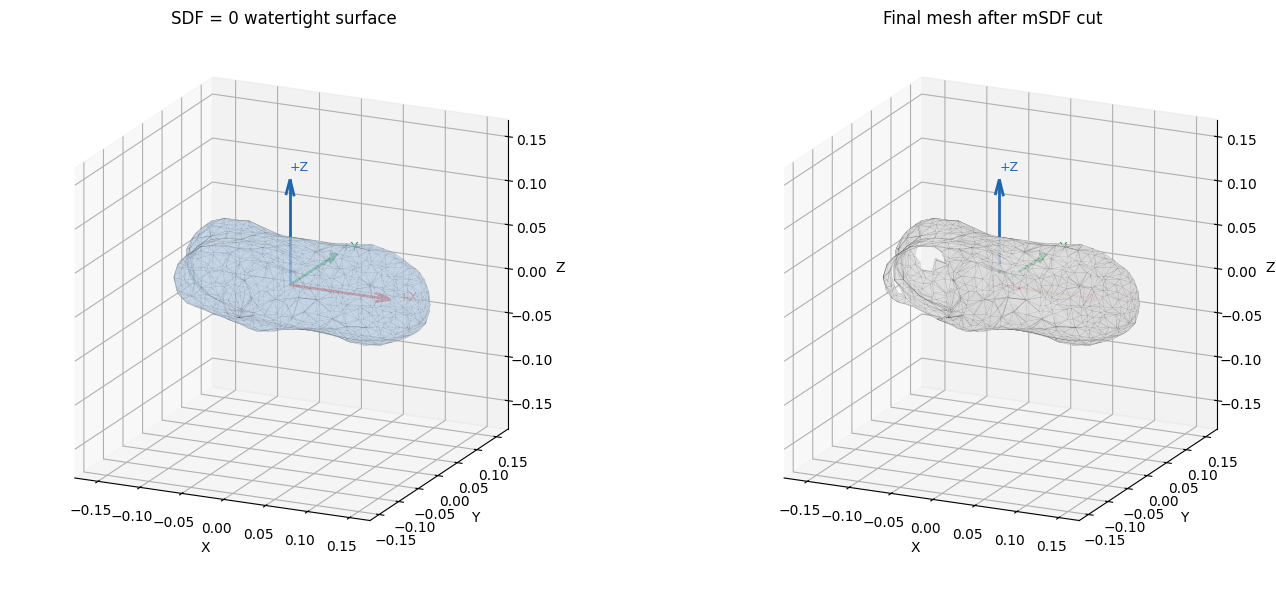

In [7]:
ELEV = 18
AZIM = -65

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
add_mesh(ax1, FIELDS["watertight_vertices"], FIELDS["watertight_faces"], color="#b8cde3", alpha=0.50)
set_axes_equal(ax1, [FIELDS["watertight_vertices"]])
add_world_axes(ax1, FIELDS["watertight_vertices"].mean(axis=0), length=0.12)
style_3d(ax1, "SDF = 0 watertight surface", ELEV, AZIM)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
add_mesh(ax2, FIELDS["final_vertices"], FIELDS["final_faces"], color="#d8d8d8", alpha=0.80)
set_axes_equal(ax2, [FIELDS["watertight_vertices"]])
add_world_axes(ax2, FIELDS["watertight_vertices"].mean(axis=0), length=0.12)
style_3d(ax2, "Final mesh after mSDF cut", ELEV, AZIM)

plt.tight_layout()

## 7. mSDF On The Watertight Surface

This is the most important view for the missing sole problem.

```text
green / positive -> kept side
white / zero     -> cut boundary
red / negative   -> removed side
```

/tmp/ipykernel_1702439/2241480869.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  poly.set_facecolor(cm.get_cmap(cmap)(norm(fvals)))


mSDF color clip: 0.2643400818109512


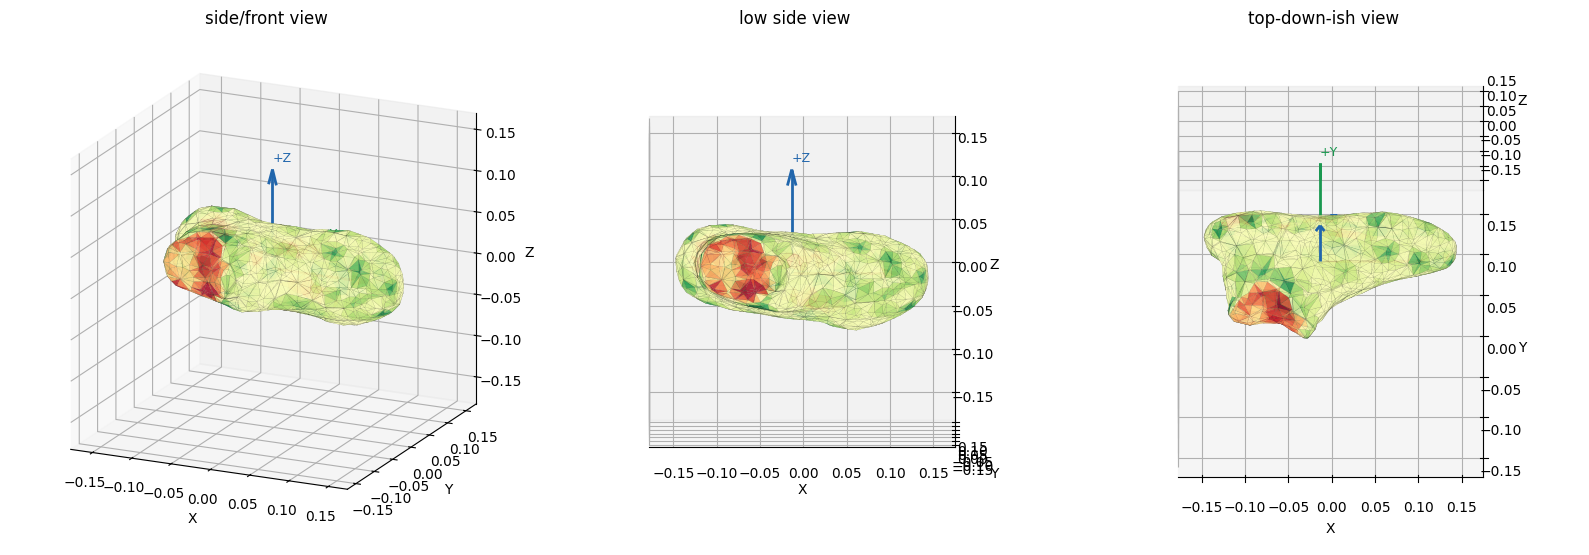

In [8]:
MSDF_CLIP = float(np.percentile(np.abs(FIELDS["watertight_msdf"]), 95))
MSDF_CLIP = max(MSDF_CLIP, 1e-3)

fig = plt.figure(figsize=(16, 7))
views = [(18, -65, "side/front view"), (5, -90, "low side view"), (70, -90, "top-down-ish view")]
for i, (elev, azim, title) in enumerate(views, 1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    add_mesh(
        ax,
        FIELDS["watertight_vertices"],
        FIELDS["watertight_faces"],
        values=FIELDS["watertight_msdf"],
        alpha=0.82,
        cmap="RdYlGn",
        clip=MSDF_CLIP,
    )
    set_axes_equal(ax, [FIELDS["watertight_vertices"]])
    add_world_axes(ax, FIELDS["watertight_vertices"].mean(axis=0), length=0.12)
    style_3d(ax, title, elev, azim)
plt.tight_layout()

print("mSDF color clip:", MSDF_CLIP)

## 8. SDF Slice Through The Tet Grid

This shows the learned SDF values on grid points near a slice plane. The zero crossing of this field creates the watertight surface.

slice points: 5392
blue/red are opposite SDF signs; the zero crossing becomes the watertight surface.


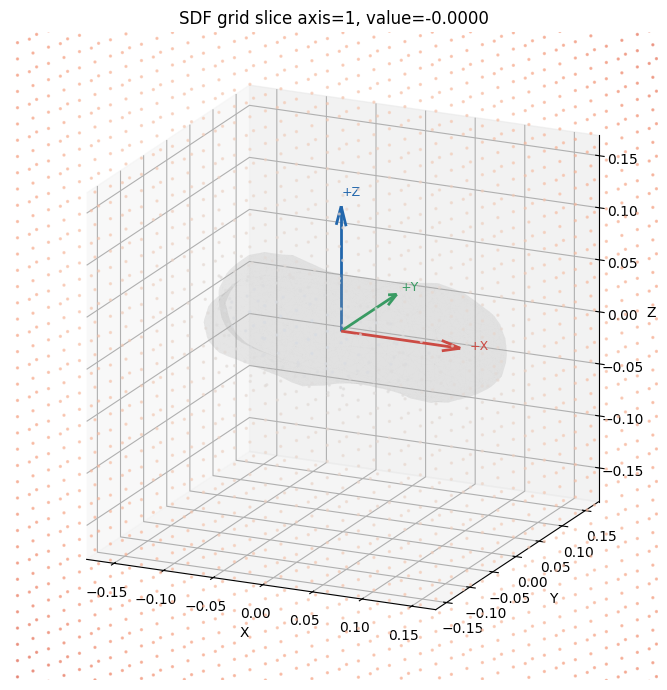

In [9]:
SLICE_AXIS = 1   # 0=X, 1=Y, 2=Z
SLICE_VALUE = float(np.median(FIELDS["tet_vertices"][:, SLICE_AXIS]))
SLICE_THICKNESS = 0.015
MAX_SLICE_POINTS = 25000

pts = FIELDS["tet_vertices"]
sdf = FIELDS["sdf"]
mask = np.abs(pts[:, SLICE_AXIS] - SLICE_VALUE) <= SLICE_THICKNESS
idx = np.where(mask)[0]
if idx.size > MAX_SLICE_POINTS:
    idx = idx[subsample_indices(idx.size, MAX_SLICE_POINTS)]

svals = sdf[idx]
clip = max(float(np.percentile(np.abs(svals), 95)), 1e-4)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1, projection="3d")
norm = colors.TwoSlopeNorm(vmin=-clip, vcenter=0.0, vmax=clip)
ax.scatter(pts[idx, 0], pts[idx, 1], pts[idx, 2], c=svals, cmap="coolwarm", norm=norm, s=2, alpha=0.55)
add_mesh(ax, FIELDS["watertight_vertices"], FIELDS["watertight_faces"], color="#aaaaaa", alpha=0.12, linewidth=0.0)
set_axes_equal(ax, [FIELDS["watertight_vertices"]])
add_world_axes(ax, FIELDS["watertight_vertices"].mean(axis=0), length=0.12)
style_3d(ax, f"SDF grid slice axis={SLICE_AXIS}, value={SLICE_VALUE:.4f}", ELEV, AZIM)
plt.tight_layout()

print("slice points:", idx.size)
print("blue/red are opposite SDF signs; the zero crossing becomes the watertight surface.")

## 9. Sole/Base mSDF Diagnostic

For the current shoe coordinate understanding, the missing base/sole is on the `+Y` side. This cell checks whether that region has negative mSDF values.

sole/base region vertex count: 328 / 1640
sole/base mSDF min / mean / max: -0.31718897819519043 0.02703510783612728 0.3480924963951111
sole/base negative fraction: 0.27439024390243905
sole/base near-zero fraction: 0.018292682926829267
whole-surface negative fraction: 0.13109756097560976


/tmp/ipykernel_1702439/2241480869.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  poly.set_facecolor(cm.get_cmap(cmap)(norm(fvals)))


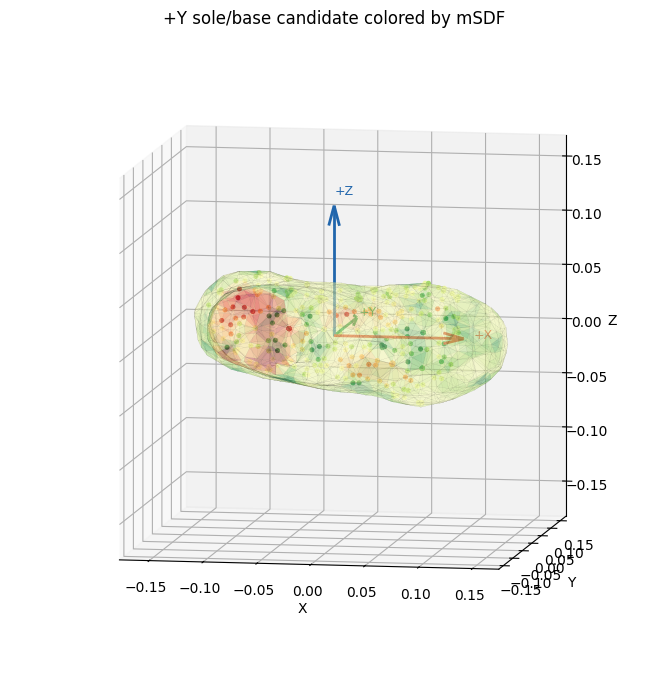

In [10]:
SOLE_AXIS = 1
SOLE_SIGN = +1
SOLE_PERCENTILE = 80

wv = FIELDS["watertight_vertices"]
wm = FIELDS["watertight_msdf"]
signed_height = SOLE_SIGN * wv[:, SOLE_AXIS]
threshold = np.percentile(signed_height, SOLE_PERCENTILE)
sole_mask = signed_height >= threshold

print("sole/base region vertex count:", int(sole_mask.sum()), "/", wv.shape[0])
print("sole/base mSDF min / mean / max:", float(wm[sole_mask].min()), float(wm[sole_mask].mean()), float(wm[sole_mask].max()))
print("sole/base negative fraction:", float((wm[sole_mask] < 0).mean()))
print("sole/base near-zero fraction:", float((np.abs(wm[sole_mask]) < 1e-3).mean()))
print("whole-surface negative fraction:", float((wm < 0).mean()))

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1, projection="3d")
add_mesh(ax, wv, FIELDS["watertight_faces"], values=wm, alpha=0.35, cmap="RdYlGn", clip=MSDF_CLIP)
idx = np.where(sole_mask)[0]
idx = idx[subsample_indices(idx.size, 12000)] if idx.size else idx
ax.scatter(wv[idx, 0], wv[idx, 1], wv[idx, 2], c=wm[idx], cmap="RdYlGn", norm=colors.TwoSlopeNorm(vmin=-MSDF_CLIP, vcenter=0, vmax=MSDF_CLIP), s=7, alpha=0.95)
set_axes_equal(ax, [wv])
add_world_axes(ax, wv.mean(axis=0), length=0.12)
style_3d(ax, "+Y sole/base candidate colored by mSDF", 8, -80)
plt.tight_layout()

## 10. Export Colored PLY Files

These files can be opened in MeshLab/Blender. They are useful when matplotlib views are not enough.

In [11]:
def values_to_rgb(values, cmap_name="RdYlGn", clip=None):
    values = np.asarray(values).reshape(-1)
    if clip is None:
        clip = max(float(np.percentile(np.abs(values), 95)), 1e-6)
    norm = colors.TwoSlopeNorm(vmin=-clip, vcenter=0.0, vmax=clip)
    rgb = cm.get_cmap(cmap_name)(norm(values))[:, :3]
    return np.clip(rgb * 255.0, 0, 255).astype(np.uint8)


def write_colored_ply(path, vertices, faces=None, values=None, cmap_name="RdYlGn", clip=None):
    vertices = np.asarray(vertices, dtype=np.float32)
    faces = None if faces is None else np.asarray(faces, dtype=np.int64)
    if values is None:
        rgb = np.full((vertices.shape[0], 3), 180, dtype=np.uint8)
    else:
        rgb = values_to_rgb(values, cmap_name=cmap_name, clip=clip)

    with open(path, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {vertices.shape[0]}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
        if faces is not None:
            f.write(f"element face {faces.shape[0]}\n")
            f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        for p, c in zip(vertices, rgb):
            f.write(f"{p[0]} {p[1]} {p[2]} {int(c[0])} {int(c[1])} {int(c[2])}\n")
        if faces is not None:
            for tri in faces:
                f.write(f"3 {int(tri[0])} {int(tri[1])} {int(tri[2])}\n")


write_colored_ply(
    DEBUG_OUT_DIR / "watertight_mesh_colored_by_msdf.ply",
    FIELDS["watertight_vertices"],
    FIELDS["watertight_faces"],
    FIELDS["watertight_msdf"],
    cmap_name="RdYlGn",
    clip=MSDF_CLIP,
)
write_colored_ply(
    DEBUG_OUT_DIR / "final_mesh_colored_by_msdf.ply",
    FIELDS["final_vertices"],
    FIELDS["final_faces"],
    FIELDS["final_msdf"],
    cmap_name="RdYlGn",
    clip=MSDF_CLIP,
)

pts = FIELDS["tet_vertices"]
sdf = FIELDS["sdf"]
near_surface = np.abs(sdf) <= np.percentile(np.abs(sdf), 5)
near_idx = np.where(near_surface)[0]
near_idx = near_idx[subsample_indices(near_idx.size, 50000)] if near_idx.size else near_idx
write_colored_ply(
    DEBUG_OUT_DIR / "near_sdf_zero_grid_points_colored_by_sdf.ply",
    pts[near_idx],
    faces=None,
    values=sdf[near_idx],
    cmap_name="coolwarm",
)

print("wrote:")
for path in sorted(DEBUG_OUT_DIR.glob("*.ply")):
    print(" ", path)

wrote:
  /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_footshell_v1_full_sdf10k/sdf_msdf_debug/final_mesh_colored_by_msdf.ply
  /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_footshell_v1_full_sdf10k/sdf_msdf_debug/near_sdf_zero_grid_points_colored_by_sdf.ply
  /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_footshell_v1_full_sdf10k/sdf_msdf_debug/watertight_mesh_colored_by_msdf.ply


/tmp/ipykernel_1702439/1269786416.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  rgb = cm.get_cmap(cmap_name)(norm(values))[:, :3]


## How To Read This

If the watertight surface has a base but the final mesh does not, the SDF is not the immediate problem. The mSDF cut is removing it.

If the sole/base region is red or has many negative mSDF values, that is direct evidence that the mSDF is treating the sole as an opening. In that case, the foot prior should push those exact sole-region mSDF values positive.